# Module 03 Lab - CNNs for Image Classification: Puppy or Bagel? 🐶🥯

Welcome to Module 03! In this lab, we will explore **Convolutional Neural Networks (CNNs)** for image classification using one of the internet's most amusing classification challenges: **Can you tell the difference between a puppy and a bagel?**

**What you'll learn:**
- CNN fundamentals: convolutional layers, pooling, and feature maps
- Building a CNN from scratch for binary image classification
- Transfer learning with pre-trained models
- Fine-tuning strategies for custom datasets

**Dataset:** Puppy or Bagel
- **Kaggle Link:** https://www.kaggle.com/datasets/returnofsputnik/puppy-or-bagel

### The Famous Meme That Started It All!
This dataset is inspired by Karen Zack's (@teenybiscuit) viral meme showing how curled-up puppies look remarkably similar to bagels!

In [231]:
# ============================================================
# DISPLAY THE FAMOUS PUPPY OR BAGEL MEME
# This cell shows the viral meme that inspired our dataset
# ============================================================

from IPython.display import Image, display, HTML

# Display the original "Puppy or Bagel" meme by Karen Zack
display(HTML('''
<div style="text-align: center; padding: 20px; background-color: #f5f5f5; border-radius: 10px;">
    <h3>🐶 The Famous "Puppy or Bagel?" Challenge 🥯</h3>
    <img src="https://static.boredpanda.com/blog/wp-content/uploads/2016/03/dog-food-comparison-bagel-muffin-lookalike-teenybiscuit-karen-zack__700.jpg"
         width="600" alt="Puppy or Bagel meme by Karen Zack">
    <p><i>Original meme by Karen Zack (@teenybiscuit) - Can YOU tell which is which?</i></p>
</div>
'''))

## Learning Objectives

By the end of this lab, you will be able to:

- **Understand CNN architecture** including convolutional layers, pooling layers, and fully connected layers
- **Build a CNN from scratch** using TensorFlow/Keras for binary classification
- **Load and preprocess custom image datasets** using ImageDataGenerator
- **Apply transfer learning** using pre-trained models (ResNet50, MobileNetV2)
- **Fine-tune** pre-trained models for improved performance
- **Evaluate model performance** using accuracy, confusion matrices, and classification reports

---
## 1. Setup and Installation

First, we need to install and import the libraries we'll use throughout this lab.

In [232]:
# ============================================================
# INSTALL REQUIRED LIBRARIES
# The -q flag means "quiet" - less output during installation
# ============================================================

!pip install -q tensorflow numpy matplotlib scikit-learn kaggle pillow seaborn

In [233]:
# ============================================================
# IMPORT ALL NECESSARY LIBRARIES
# Each library serves a specific purpose in our ML pipeline
# ============================================================

# TensorFlow/Keras - Our main deep learning framework
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# Pre-trained models for transfer learning
from tensorflow.keras.applications import ResNet50, VGG16, MobileNetV2

# For loading images and applying data augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# NumPy - For numerical operations on arrays
import numpy as np

# Matplotlib - For plotting graphs and displaying images
import matplotlib.pyplot as plt

# Scikit-learn - For evaluation metrics (confusion matrix, etc.)
from sklearn.metrics import classification_report, confusion_matrix

# Seaborn - For prettier statistical visualizations
import seaborn as sns

# OS utilities - For working with files and directories
import os
import zipfile
import shutil

# Print version information and check for GPU availability
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Detect if we're running in Google Colab
try:
    import google.colab
    IN_COLAB = True
    print("✅ Running in Google Colab")
except:
    IN_COLAB = False
    print("💻 Running locally")

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Running in Google Colab


---
## 2. Download and Prepare the Dataset

## 🌟 FOR GOOGLE COLAB FREE USERS 🌟

**Important Setup Steps:**
1. Go to **Runtime → Change runtime type → GPU** (makes training MUCH faster!)
2. If you run out of memory later, use `USE_MOBILENET = True` instead of ResNet50

---

### Option A: Download via Kaggle API (Recommended)

**How to get your Kaggle API key:**
1. Go to [kaggle.com](https://www.kaggle.com) → Click your profile icon → **Settings**
2. Scroll to **API** section → Click **"Create New Token"**
3. This downloads a `kaggle.json` file - upload it when prompted below

In [201]:
# ============================================================
# SETUP KAGGLE API CREDENTIALS
# This allows us to download datasets directly from Kaggle
# ============================================================

if IN_COLAB:
    from google.colab import files

    print("📤 Please upload your kaggle.json file:")
    print("   (Get it from: kaggle.com → Profile → Settings → API → Create New Token)\n")

    # This will prompt you to upload a file
    uploaded = files.upload()

    # Move the kaggle.json to the correct location
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json  # Set proper permissions

    print("\n✅ Kaggle credentials configured!")
else:
    print("Not in Colab - make sure kaggle.json is in ~/.kaggle/")

📤 Please upload your kaggle.json file:
   (Get it from: kaggle.com → Profile → Settings → API → Create New Token)



Saving kaggle.json to kaggle (6).json

✅ Kaggle credentials configured!


In [202]:
# ============================================================
# DOWNLOAD THE DATASET FROM KAGGLE
# This downloads and extracts the puppy-or-bagel dataset
# ============================================================

# Download the dataset (this may take a minute)
!kaggle datasets download -d returnofsputnik/puppy-or-bagel

# Unzip the dataset (-q = quiet, -o = overwrite if exists)
!unzip -q -o puppy-or-bagel.zip -d puppy-or-bagel

print("\n✅ Dataset downloaded and extracted!")
print("\n📂 Contents:")
!ls -la puppy-or-bagel/

Dataset URL: https://www.kaggle.com/datasets/returnofsputnik/puppy-or-bagel
License(s): unknown
puppy-or-bagel.zip: Skipping, found more recently modified local copy (use --force to force download)

✅ Dataset downloaded and extracted!

📂 Contents:
total 240
drwxr-xr-x 3 root root  4096 Feb  5 03:10 .
drwxr-xr-x 1 root root  4096 Feb  5 03:10 ..
-rw-r--r-- 1 root root 11279 Jan 13  2021 bagel-1.jpg
-rw-r--r-- 1 root root 11768 Jan 13  2021 bagel-2.jpg
-rw-r--r-- 1 root root 10897 Jan 13  2021 bagel-3.jpg
-rw-r--r-- 1 root root 12433 Jan 13  2021 bagel-4.jpg
-rw-r--r-- 1 root root 10468 Jan 13  2021 bagel-5.jpg
-rw-r--r-- 1 root root 14102 Jan 13  2021 bagel-6.jpg
-rw-r--r-- 1 root root 14014 Jan 13  2021 bagel-7.jpg
-rw-r--r-- 1 root root 10523 Jan 13  2021 bagel-8.jpg
-rw-r--r-- 1 root root 13258 Jan 13  2021 dog-1.jpg
-rw-r--r-- 1 root root 13644 Jan 13  2021 dog-2.jpg
-rw-r--r-- 1 root root 11949 Jan 13  2021 dog-3.jpg
-rw-r--r-- 1 root root 12622 Jan 13  2021 dog-4.jpg
-rw-r--r-- 1 

### Option B: Manual Download (If Kaggle API doesn't work)

1. Visit: https://www.kaggle.com/datasets/returnofsputnik/puppy-or-bagel
2. Click **"Download"** (requires free Kaggle account)
3. In Colab: Click 📁 folder icon on left → Upload the zip file
4. Uncomment and run the cell below

In [203]:
# ============================================================
# OPTION B: MANUAL UPLOAD (Only if Kaggle API fails)
# Uncomment these lines if you uploaded the zip manually
# ============================================================

# !unzip -q -o puppy-or-bagel.zip -d puppy-or-bagel
# print("✅ Extracted!")

In [204]:
# ============================================================
# EXPLORE THE DATASET STRUCTURE
# This helps us understand how the files are organized
# ============================================================

DATASET_PATH = 'puppy-or-bagel'

print("📂 Dataset structure:\n")
for root, dirs, files_list in os.walk(DATASET_PATH):
    # Calculate how deep we are in the directory tree
    level = root.replace(DATASET_PATH, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")

    # Only show first 2 levels to keep output clean
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for d in dirs[:5]:  # Show max 5 subdirectories
            print(f"{subindent}{d}/")
        if len(files_list) > 0:
            print(f"{subindent}({len(files_list)} files)")

📂 Dataset structure:

puppy-or-bagel/
  organized_data/
  (16 files)
  organized_data/
    train/
    validation/
    train/
      puppy/
      bagel/
    validation/
      puppy/
      bagel/


In [205]:
# ============================================================
# AUTO-DETECT DATA DIRECTORIES
# This function finds train/valid/test folders automatically
# ============================================================

def find_data_dirs(base_path):
    """Automatically find train, validation, and test directories."""
    train_dir = valid_dir = test_dir = None

    # Look for directories with common naming patterns
    for item in os.listdir(base_path):
        item_path = os.path.join(base_path, item)
        if os.path.isdir(item_path):
            item_lower = item.lower()
            if 'train' in item_lower:
                train_dir = item_path
            elif 'valid' in item_lower or 'val' in item_lower:
                valid_dir = item_path
            elif 'test' in item_lower:
                test_dir = item_path

    return train_dir, valid_dir, test_dir

# Find the directories
train_dir, valid_dir, test_dir = find_data_dirs(DATASET_PATH)

# If not found at top level, check one level deeper
if train_dir is None:
    for item in os.listdir(DATASET_PATH):
        item_path = os.path.join(DATASET_PATH, item)
        if os.path.isdir(item_path):
            train_dir, valid_dir, test_dir = find_data_dirs(item_path)
            if train_dir:
                break

# Display what we found
print(f"📁 Train directory: {train_dir}")
print(f"📁 Validation directory: {valid_dir}")
print(f"📁 Test directory: {test_dir}")

# Count images in each class
if train_dir:
    print("\n📊 Training data breakdown:")
    for cls in os.listdir(train_dir):
        cls_path = os.path.join(train_dir, cls)
        if os.path.isdir(cls_path):
            count = len([f for f in os.listdir(cls_path)
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            print(f"   {cls}: {count} images")

📁 Train directory: puppy-or-bagel/organized_data/train
📁 Validation directory: puppy-or-bagel/organized_data/validation
📁 Test directory: None

📊 Training data breakdown:
   puppy: 6 images
   bagel: 6 images


In [206]:
# ============================================================
# SET TRAINING PARAMETERS (OPTIMIZED FOR COLAB FREE)
# These settings balance training quality with resource limits
# ============================================================

if IN_COLAB:
    # Check if GPU is available
    gpu_available = len(tf.config.list_physical_devices('GPU')) > 0

    if gpu_available:
        print("✅ GPU detected! Using standard settings.")
        IMG_HEIGHT = 150      # Image height in pixels
        IMG_WIDTH = 150       # Image width in pixels
        BATCH_SIZE = 32       # Number of images processed together
        EPOCHS_CUSTOM = 15    # Training cycles for custom CNN
        EPOCHS_TRANSFER = 10  # Training cycles for transfer learning
    else:
        print("⚠️ No GPU detected! Using memory-efficient settings.")
        print("   💡 Tip: Go to Runtime → Change runtime type → GPU")
        IMG_HEIGHT = 100
        IMG_WIDTH = 100
        BATCH_SIZE = 16
        EPOCHS_CUSTOM = 8
        EPOCHS_TRANSFER = 5
else:
    # Local machine settings
    IMG_HEIGHT = 150
    IMG_WIDTH = 150
    BATCH_SIZE = 32
    EPOCHS_CUSTOM = 15
    EPOCHS_TRANSFER = 10

# Class names (alphabetical order - how Keras reads directories)
class_names = ['bagel', 'puppy']

print(f"\n📊 Training Configuration:")
print(f"   Image size: {IMG_HEIGHT}x{IMG_WIDTH} pixels")
print(f"   Batch size: {BATCH_SIZE} images")
print(f"   Custom CNN epochs: {EPOCHS_CUSTOM}")
print(f"   Transfer learning epochs: {EPOCHS_TRANSFER}")

✅ GPU detected! Using standard settings.

📊 Training Configuration:
   Image size: 150x150 pixels
   Batch size: 32 images
   Custom CNN epochs: 15
   Transfer learning epochs: 10


---
## 3. Understanding CNNs

### What makes CNNs special for images?

**Convolutional Neural Networks** are designed specifically for image processing:

1. **Preserve spatial relationships** - Nearby pixels stay connected
2. **Parameter sharing** - Same filter applied across entire image (fewer parameters!)
3. **Hierarchical features** - Learn edges → textures → shapes → objects

### Key Components:
| Layer | Purpose |
|-------|--------|
| **Conv2D** | Applies filters to detect features like edges and textures |
| **MaxPooling2D** | Reduces image size while keeping important information |
| **Flatten** | Converts 2D feature maps to 1D for classification |
| **Dense** | Fully connected layers for final decision making |
| **Dropout** | Randomly disables neurons to prevent overfitting |

### The Puppy vs Bagel Challenge:
Both puppies and bagels share visual features:
- ✓ Round, circular shapes
- ✓ Tan/brown coloring  
- ✓ Textured surfaces

Our CNN must learn the subtle differences!

---
## 4. Load and Explore the Dataset

In [207]:
# ============================================================
# CREATE DATA GENERATORS WITH AUGMENTATION
#
# Data augmentation creates variations of our images to help
# the model generalize better and prevent overfitting.
# Think of it as showing the model the same puppy from
# different angles and lighting conditions!
# ============================================================

# Training generator - includes data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixels from 0-255 to 0-1
    rotation_range=20,         # Rotate images randomly up to 20°
    width_shift_range=0.2,     # Shift images horizontally
    height_shift_range=0.2,    # Shift images vertically
    shear_range=0.2,           # Apply shear transformation
    zoom_range=0.2,            # Randomly zoom in/out
    horizontal_flip=True,      # Flip images left-right
    fill_mode='nearest'        # How to fill new pixels
)

# Validation/Test generator - NO augmentation!
# We want to test on real, unmodified images
test_datagen = ImageDataGenerator(rescale=1./255)

print("✅ Data generators created!")
print("📝 Training images will be augmented (rotated, flipped, etc.)")
print("📝 Validation/Test images will only be normalized")

✅ Data generators created!
📝 Training images will be augmented (rotated, flipped, etc.)
📝 Validation/Test images will only be normalized


In [208]:
# ============================================================
# FIX: REORGANIZE DATASET FOR flow_from_directory
# The dataset was downloaded as a flat structure (all images in 'puppy-or-bagel/').
# However, `flow_from_directory` expects images to be in class-named subdirectories
# within a main directory (e.g., 'train/bagel', 'train/puppy').
# This code creates the required directory structure and moves the images.
# ============================================================
import random

# Define paths for the new, organized dataset structure
base_dir_organized = os.path.join(DATASET_PATH, 'organized_data')
train_dir_new = os.path.join(base_dir_organized, 'train')
validation_dir_new = os.path.join(base_dir_organized, 'validation')

# --- FIX START: Remove organized_data directory if it already exists ---
if os.path.exists(base_dir_organized):
    print(f"Removing existing organized_data directory: {base_dir_organized}")
    shutil.rmtree(base_dir_organized)
# --- FIX END ---

# Define class directories
train_bagel_path = os.path.join(train_dir_new, 'bagel')
train_puppy_path = os.path.join(train_dir_new, 'puppy')
validation_bagel_path = os.path.join(validation_dir_new, 'bagel')
validation_puppy_path = os.path.join(validation_dir_new, 'puppy')

# Create all necessary directories
for path in [train_bagel_path, train_puppy_path, validation_bagel_path, validation_puppy_path]:
    os.makedirs(path, exist_ok=True)

print("Created new dataset directories for organized data.")

# List all original image files and categorize them
# NOTE: Need to list from the original DATASET_PATH again,
# as they might have been moved in a previous (failed) run.
# However, it's safer to ensure they are back to their original state
# or check for existing files before moving. For simplicity,
# assuming clean slate after rmtree.
all_original_files_to_move = [os.path.join(DATASET_PATH, f) for f in os.listdir(DATASET_PATH)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

bagel_files = [f for f in all_original_files_to_move if 'bagel' in os.path.basename(f).lower()]
puppy_files = [f for f in all_original_files_to_move if 'dog' in os.path.basename(f).lower()]

# Shuffle files to ensure random split
random.shuffle(bagel_files)
random.shuffle(puppy_files)

# Define split ratio (e.g., 80% for training, 20% for validation)
train_split_ratio = 0.8

# Move bagel files
num_train_bagel = int(len(bagel_files) * train_split_ratio)
for i, fname in enumerate(bagel_files):
    # Ensure file still exists in source before trying to move
    if os.path.exists(fname):
        if i < num_train_bagel:
            shutil.move(fname, train_bagel_path)
        else:
            shutil.move(fname, validation_bagel_path)

# Move puppy files
num_train_puppy = int(len(puppy_files) * train_split_ratio)
for i, fname in enumerate(puppy_files):
    # Ensure file still exists in source before trying to move
    if os.path.exists(fname):
        if i < num_train_puppy:
            shutil.move(fname, train_puppy_path)
        else:
            shutil.move(fname, validation_puppy_path)

print(f"Moved {len(bagel_files)} bagel images and {len(puppy_files)} puppy images into organized directories.")

# Update the directory variables used by flow_from_directory
train_dir = train_dir_new
valid_dir = validation_dir_new
# If no explicit test set is created, use validation data for testing as per original notebook logic
test_dir = validation_dir_new

print("\n✅ Dataset reorganized and directory paths updated!")
print(f"   New Train directory: {train_dir}")
print(f"   New Validation directory: {valid_dir}")
print(f"   New Test directory (using validation data): {test_dir}")

# ============================================================
# CREATE DATA GENERATORS WITH AUGMENTATION
#
# Data augmentation creates variations of our images to help
# the model generalize better and prevent overfitting.
# Think of it as showing the model the same puppy from
# different angles and lighting conditions!
# ============================================================

# Training generator - includes data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixels from 0-255 to 0-1
    rotation_range=20,         # Rotate images randomly up to 20°
    width_shift_range=0.2,     # Shift images horizontally
    height_shift_range=0.2,    # Shift images vertically
    shear_range=0.2,           # Apply shear transformation
    zoom_range=0.2,            # Randomly zoom in/out
    horizontal_flip=True,      # Flip images left-right
    fill_mode='nearest'        # How to fill new pixels
)

# Validation/Test generator - NO augmentation!
# We want to test on real, unmodified images
test_datagen = ImageDataGenerator(rescale=1./255)

print("✅ Data generators created!")
print("📝 Training images will be augmented (rotated, flipped, etc.)")
print("📝 Validation/Test images will only be normalized")

# ============================================================
# LOAD IMAGES FROM DIRECTORIES
#
# flow_from_directory() is a powerful function that:
# - Automatically loads images from folders
# - Uses folder names as class labels
# - Resizes all images to the same size
# - Creates batches for efficient training
# ============================================================

# Load training data
train_generator = train_datagen.flow_from_directory(
    train_dir,                              # Path to training images
    target_size=(IMG_HEIGHT, IMG_WIDTH),    # Resize images
    batch_size=BATCH_SIZE,                  # Images per batch
    class_mode='binary',                    # Binary: puppy vs bagel
    shuffle=True                            # Randomize order
)

# Load validation data (if available)
if valid_dir:
    validation_generator = test_datagen.flow_from_directory(
        valid_dir,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False  # Don't shuffle - keep consistent order
    )
else:
    validation_generator = None
    print("⚠️ No validation directory found")

# Load test data (if available)
if test_dir:
    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )
else:
    test_generator = validation_generator
    print("⚠️ Using validation data for testing")

# Show the class mapping
print(f"\n📊 Class mapping: {train_generator.class_indices}")
print(f"   This means: 0 = bagel, 1 = puppy")

Removing existing organized_data directory: puppy-or-bagel/organized_data
Created new dataset directories for organized data.
Moved 8 bagel images and 8 puppy images into organized directories.

✅ Dataset reorganized and directory paths updated!
   New Train directory: puppy-or-bagel/organized_data/train
   New Validation directory: puppy-or-bagel/organized_data/validation
   New Test directory (using validation data): puppy-or-bagel/organized_data/validation
✅ Data generators created!
📝 Training images will be augmented (rotated, flipped, etc.)
📝 Validation/Test images will only be normalized
Found 12 images belonging to 2 classes.
Found 4 images belonging to 2 classes.
Found 4 images belonging to 2 classes.

📊 Class mapping: {'bagel': 0, 'puppy': 1}
   This means: 0 = bagel, 1 = puppy


/tmp/ipython-input-3403330712.py:27: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3403330712.py:27: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


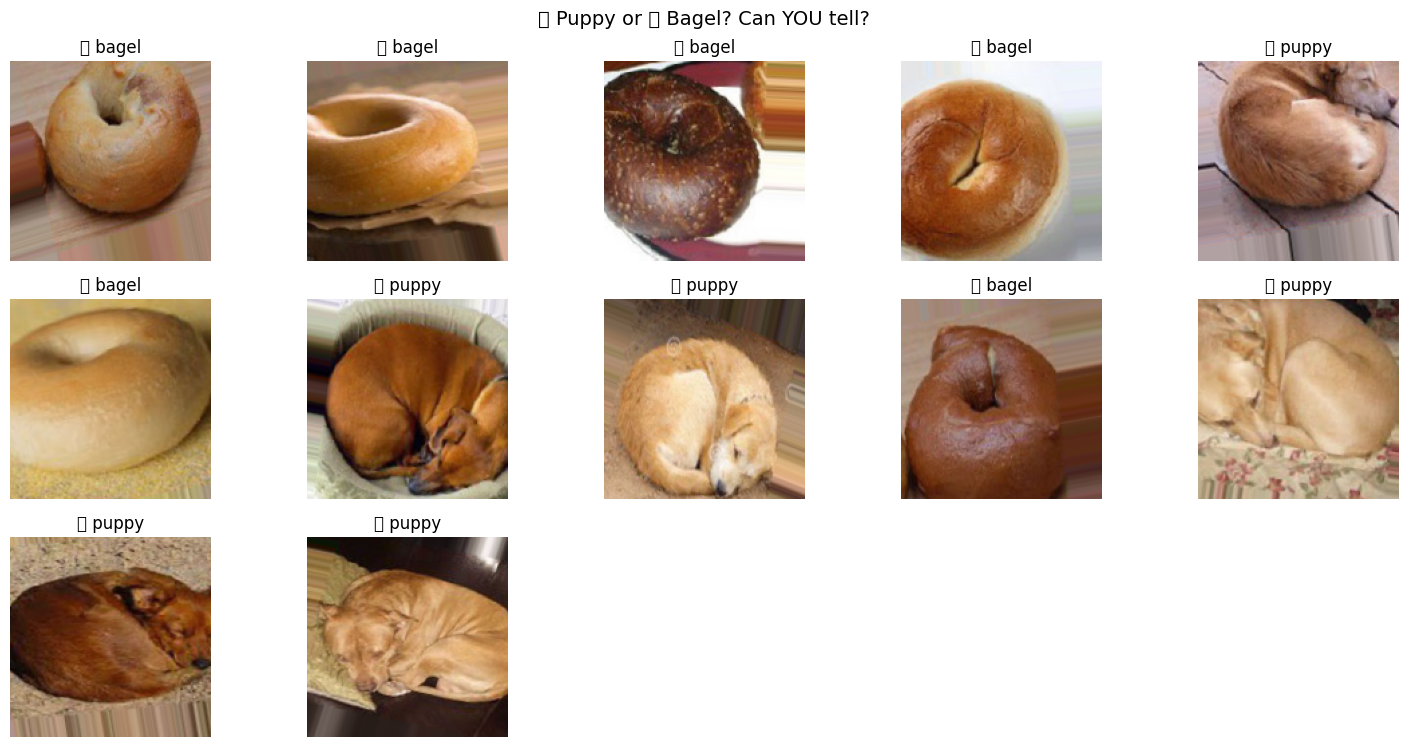

In [209]:
# ============================================================
# VISUALIZE SAMPLE IMAGES
#
# Let's see what our puppies and bagels look like!
# Can you tell which is which?
# ============================================================

def show_batch(generator, class_names, num=20):
    """Display a grid of images from the generator."""
    # Get one batch of images and labels
    images, labels = next(generator)

    # Create figure with subplots
    plt.figure(figsize=(15, 10))

    for i in range(min(num, len(images))):
        plt.subplot(4, 5, i + 1)  # 4 rows × 5 columns
        plt.imshow(images[i])      # Show the image

        # Add label with emoji
        label_idx = int(labels[i])
        emoji = '🐶' if class_names[label_idx] == 'puppy' else '🥯'
        plt.title(f"{emoji} {class_names[label_idx]}")
        plt.axis('off')  # Hide axes

    plt.suptitle("🐶 Puppy or 🥯 Bagel? Can YOU tell?", fontsize=14)
    plt.tight_layout()
    plt.show()

# Display sample images
show_batch(train_generator, class_names)

---
## 5. Part 1: Build a Custom CNN from Scratch 🏗️

Now it's YOUR turn to build a CNN! You'll complete several sections yourself.

### Our CNN Architecture Plan:
```
Input (150×150×3)
    ↓
Conv2D(32 filters) → ReLU → MaxPooling2D
    ↓
Conv2D(64 filters) → ReLU → MaxPooling2D
    ↓
Conv2D(128 filters) → ReLU → MaxPooling2D    ← YOU CODE THIS
    ↓
Conv2D(128 filters) → ReLU → MaxPooling2D    ← YOU CODE THIS
    ↓
Flatten
    ↓
Dense(512) → ReLU → Dropout(0.5)             ← YOU CODE THIS
    ↓
Dense(1) → Sigmoid                            ← YOU CODE THIS
    ↓
Output (0 = bagel, 1 = puppy)
```

In [210]:
# ============================================================
# BUILD CNN - STEP 1: CREATE MODEL AND FIRST TWO BLOCKS
#
# We'll start with Sequential API and add the first two
# convolutional blocks (provided for you as example)
# ============================================================

# Create a Sequential model - layers are added in order
model_custom = models.Sequential([

    # ========== FIRST CONVOLUTIONAL BLOCK ==========
    # Conv2D: Creates 32 different 3x3 filters to detect features
    # - 32 = number of filters (feature detectors)
    # - (3,3) = filter size (3x3 pixels)
    # - activation='relu' = ReLU makes negative values zero
    # - input_shape = (height, width, channels) for RGB images
    layers.Conv2D(32, (3, 3), activation='relu',
                  input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # MaxPooling: Reduces image size by taking max in 2x2 windows
    # This makes the model focus on the strongest features
    layers.MaxPooling2D((2, 2)),

    # ========== SECOND CONVOLUTIONAL BLOCK ==========
    # More filters (64) to detect more complex patterns
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
])

print("✅ Created model with first two convolutional blocks!")
print("\n📐 Current model architecture:")
model_custom.summary()

✅ Created model with first two convolutional blocks!

📐 Current model architecture:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,392 (75.75 KB)

 Trainable params: 19,392 (75.75 KB)

 Non-trainable params: 0 (0.00 B)

### ✏️ YOUR TURN: Add the Third Convolutional Block

**Task:** Add a convolutional block with **128 filters**

**What to add:**
1. `Conv2D` layer with 128 filters, (3,3) kernel, ReLU activation
2. `MaxPooling2D` layer with (2,2) pool size

**Syntax help:**
```python
model_custom.add(layers.Conv2D(num_filters, (3, 3), activation='relu'))
model_custom.add(layers.MaxPooling2D((2, 2)))
```

In [211]:
# ============================================================
# YOUR CODE HERE: ADD THE THIRD CONVOLUTIONAL BLOCK
#
# Instructions:
# 1. Add Conv2D with 128 filters, kernel (3,3), activation 'relu'
# 2. Add MaxPooling2D with pool size (2,2)
# ============================================================

# Third convolutional block - 128 filters
model_custom.add(layers.Conv2D(128, (3, 3), activation='relu'))

# MaxPooling
model_custom.add(layers.MaxPooling2D((2, 2)))


print("Third block added! Check the summary below:")
model_custom.summary()

Third block added! Check the summary below:


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,248 (364.25 KB)

 Trainable params: 93,248 (364.25 KB)

 Non-trainable params: 0 (0.00 B)

### ✏️ YOUR TURN: Add the Fourth Convolutional Block

**Task:** Add another convolutional block with **128 filters** (same as third block)

In [212]:
# ============================================================
# YOUR CODE HERE: ADD THE FOURTH CONVOLUTIONAL BLOCK
#
# Same as the third block: Conv2D(128) + MaxPooling2D
# ============================================================

# Fourth convolutional block - 128 filters
model_custom.add(layers.Conv2D(128, (3, 3), activation='relu'))
model_custom.add(layers.MaxPooling2D((2, 2)))


print("Fourth block added! You should now have 4 conv2d layers:")
model_custom.summary()

Fourth block added! You should now have 4 conv2d layers:


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 240,832 (940.75 KB)

 Trainable params: 240,832 (940.75 KB)

 Non-trainable params: 0 (0.00 B)

### ✏️ YOUR TURN: Add the Classification Layers

Now we need to add the "head" of our network that makes the final classification decision.

**What to add (in order):**
1. `Flatten()` - Converts 2D feature maps to 1D vector
2. `Dense(512, activation='relu')` - Fully connected layer with 512 neurons
3. `Dropout(0.5)` - Randomly turns off 50% of neurons (prevents overfitting)
4. `Dense(1, activation='sigmoid')` - Output: probability of being a puppy

**Syntax help:**
```python
model_custom.add(layers.Flatten())
model_custom.add(layers.Dense(units, activation='relu'))
model_custom.add(layers.Dropout(rate))  # rate is between 0 and 1
```

In [213]:
# ============================================================
# YOUR CODE HERE: ADD THE CLASSIFICATION LAYERS
#
# Add these 4 layers in order:
# 1. Flatten()
# 2. Dense(512, activation='relu')
# 3. Dropout(0.5)
# 4. Dense(1, activation='sigmoid')
# ============================================================

# Flatten - converts 2D to 1D
model_custom.add(layers.Flatten())


# Dense layer with 512 neurons
model_custom.add(layers.Dense(512, activation='relu'))


# Dropout for regularization (50% = 0.5)
model_custom.add(layers.Dropout(0.5))


# Output layer - 1 neuron with sigmoid for binary classification
# Sigmoid outputs a probability between 0 and 1
model_custom.add(layers.Dense(1, activation='sigmoid'))


print("\n📐 COMPLETE MODEL ARCHITECTURE:")
model_custom.summary()


📐 COMPLETE MODEL ARCHITECTURE:


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

### ✏️ YOUR TURN: Compile the Model

Before training, we must **compile** the model to configure:
- **Optimizer**: How to update weights (use `'adam'`)
- **Loss function**: What to minimize (use `'binary_crossentropy'` for binary classification)
- **Metrics**: What to track (use `['accuracy']`)

**Syntax:**
```python
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
```

In [214]:
# ============================================================
# YOUR CODE HERE: COMPILE THE MODEL
#
# Use:
# - optimizer: 'adam'
# - loss: 'binary_crossentropy'
# - metrics: ['accuracy']
# ============================================================

model_custom.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("✅ Model compiled and ready to train!")

✅ Model compiled and ready to train!


In [215]:
# ============================================================
# CALCULATE TRAINING STEPS
#
# steps_per_epoch = how many batches to process per epoch
# This is: total_samples ÷ batch_size
# ============================================================

steps_per_epoch = train_generator.samples // BATCH_SIZE
validation_steps = validation_generator.samples // BATCH_SIZE if validation_generator else None

print(f"📊 Training setup:")
print(f"   Total training images: {train_generator.samples}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Steps per epoch: {steps_per_epoch}")
print(f"   Total epochs: {EPOCHS_CUSTOM}")

📊 Training setup:
   Total training images: 12
   Batch size: 32
   Steps per epoch: 0
   Total epochs: 15


In [216]:
# ============================================================
# SETUP CALLBACKS FOR SMARTER TRAINING
#
# Callbacks are functions that run during training:
# - EarlyStopping: Stop if no improvement (saves time!)
# - ModelCheckpoint: Save best model (important for Colab!)
# ============================================================

callbacks = [
    # EarlyStopping: Stop if validation loss doesn't improve
    keras.callbacks.EarlyStopping(
        monitor='val_loss',         # Watch this metric
        patience=5,                  # Wait 5 epochs for improvement
        restore_best_weights=True    # Go back to best weights
    ),

    # ModelCheckpoint: Save best model during training
    keras.callbacks.ModelCheckpoint(
        'best_custom_model.keras',   # Filename
        monitor='val_accuracy',       # Save when this improves
        save_best_only=True,          # Only keep the best
        verbose=1                     # Print when saving
    )
]

print("✅ Callbacks configured!")

✅ Callbacks configured!


In [217]:
# ============================================================
# TRAIN THE CUSTOM CNN
#
# This is where the magic happens!
# The model learns from the training data over multiple epochs.
# Watch the accuracy improve!
# ============================================================

# FIX: Adding the compile step here, as it was missed in a previous cell.
# Ideally, this should be in the designated compile cell (rPkE81GteKUg).
# Also, ensure you have completed the model architecture in prior 'YOUR TURN' cells.
model_custom.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\n🚀 Training the Puppy vs Bagel classifier...")
print("   This may take several minutes.\n")

history_custom = model_custom.fit(
    train_generator,                     # Training data
    steps_per_epoch=steps_per_epoch,     # Batches per epoch
    epochs=EPOCHS_CUSTOM,                # Number of epochs
    validation_data=validation_generator, # Validation data
    validation_steps=validation_steps,   # Validation batches
    callbacks=callbacks,                 # Our callbacks
    verbose=1                            # Show progress
)

print("\n✅ Training complete!")


🚀 Training the Puppy vs Bagel classifier...
   This may take several minutes.

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.5833 - loss: 0.6929
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to best_custom_model.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.5833 - loss: 0.6929 - val_accuracy: 0.5000 - val_loss: 0.7045
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5000 - loss: 0.6950
Epoch 2: val_accuracy did not improve from 0.50000
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.5000 - loss: 0.6950 - val_accuracy: 0.5000 - val_loss: 0.7022
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.6667 - loss: 0.6562
Epoch 3: val_accuracy improved from 0.50000 to 0.75000, saving model to best_custom_model.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.6667 - loss: 0.6562 - val_accuracy: 0.7500 - val_loss: 0.6833
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.6667 - loss: 0.6793
Epoch 4: val_accuracy did not improve from 0.75000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 

/tmp/ipython-input-1848403022.py:30: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1848403022.py:30: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


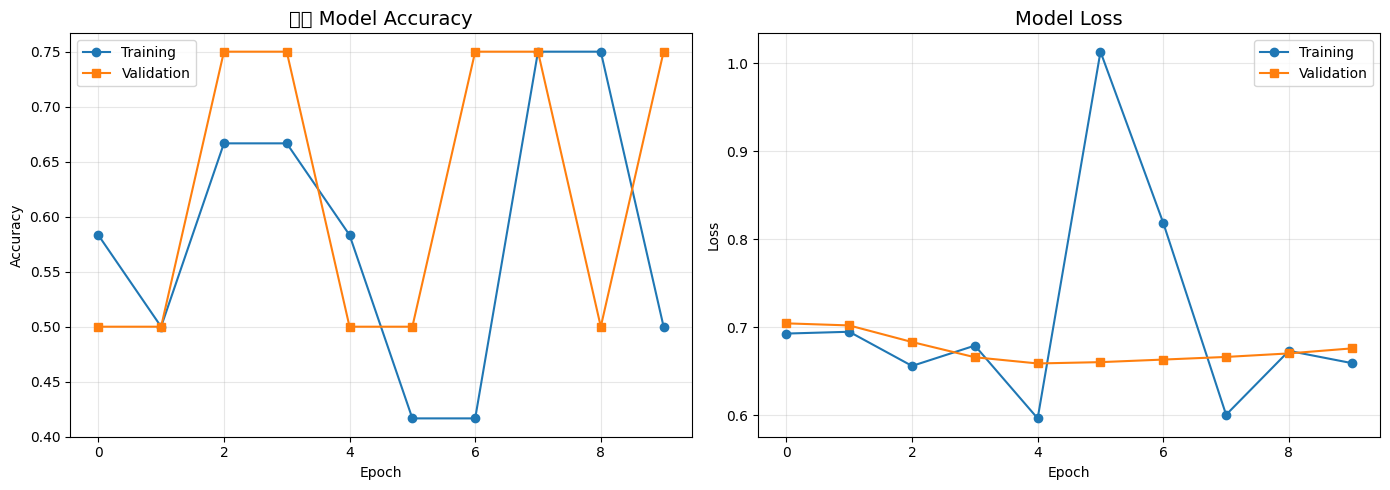


📊 How to read these plots:
   • Lines close together = Good generalization
   • Validation worse than training = Overfitting
   • Both lines plateau = Model has converged


In [218]:
# ============================================================
# VISUALIZE TRAINING HISTORY
#
# These plots help us understand how training went:
# - Accuracy plot: Should increase over time
# - Loss plot: Should decrease over time
# - Gap between train/val lines indicates overfitting
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
ax1.plot(history_custom.history['accuracy'], label='Training', marker='o')
ax1.plot(history_custom.history['val_accuracy'], label='Validation', marker='s')
ax1.set_title('🐶🥯 Model Accuracy', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot Loss
ax2.plot(history_custom.history['loss'], label='Training', marker='o')
ax2.plot(history_custom.history['val_loss'], label='Validation', marker='s')
ax2.set_title('Model Loss', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 How to read these plots:")
print("   • Lines close together = Good generalization")
print("   • Validation worse than training = Overfitting")
print("   • Both lines plateau = Model has converged")

In [219]:
# ============================================================
# EVALUATE ON TEST SET
#
# The true test of our model - how well does it perform
# on images it has never seen before?
# ============================================================

if test_generator:
    test_generator.reset()  # Reset to start of test data
    test_loss, test_acc = model_custom.evaluate(test_generator, verbose=0)

    print(f"\n📊 Custom CNN Results:")
    print(f"   Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"   Test Loss: {test_loss:.4f}")


📊 Custom CNN Results:
   Test Accuracy: 0.5000 (50.00%)
   Test Loss: 0.6590


---
## 6. Part 2: Transfer Learning with Pre-trained Models

Transfer learning uses models already trained on millions of images. We just add our own classification layers on top! This usually gives better results with less training time.

### ⚠️ Colab Free Tier Tips:
If you get **"Out of Memory"** errors:
1. Set `USE_MOBILENET = True` below (smaller model)
2. Restart runtime: Runtime → Restart runtime

In [220]:
# ============================================================
# CHOOSE YOUR PRE-TRAINED MODEL
#
# MobileNetV2: Smaller, faster (good for Colab Free)
# ResNet50: Larger, more powerful
# ============================================================

# Change to True if you're running out of memory!
USE_MOBILENET = False

if USE_MOBILENET:
    IMG_SIZE_TRANSFER = 128
    print("📱 Using MobileNetV2 (lightweight, great for Colab Free)")
else:
    IMG_SIZE_TRANSFER = 224
    print("🔬 Using ResNet50 (powerful, needs more memory)")

🔬 Using ResNet50 (powerful, needs more memory)


In [221]:
# ============================================================
# CREATE DATA GENERATORS FOR TRANSFER LEARNING
#
# Pre-trained models expect specific image sizes:
# - ResNet50/VGG16: 224×224
# - MobileNetV2: 128×128 (or 224×224)
# ============================================================

train_gen_tf = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE_TRANSFER, IMG_SIZE_TRANSFER),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

if valid_dir:
    val_gen_tf = test_datagen.flow_from_directory(
        valid_dir,
        target_size=(IMG_SIZE_TRANSFER, IMG_SIZE_TRANSFER),
        batch_size=BATCH_SIZE,
        class_mode='binary'
    )

if test_dir:
    test_gen_tf = test_datagen.flow_from_directory(
        test_dir,
        target_size=(IMG_SIZE_TRANSFER, IMG_SIZE_TRANSFER),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )
else:
    test_gen_tf = val_gen_tf

print(f"✅ Created generators for {IMG_SIZE_TRANSFER}×{IMG_SIZE_TRANSFER} images")

Found 12 images belonging to 2 classes.
Found 4 images belonging to 2 classes.
Found 4 images belonging to 2 classes.
✅ Created generators for 224×224 images


In [222]:
# ============================================================
# LOAD THE PRE-TRAINED MODEL
#
# Key parameters:
# - weights='imagenet': Use weights trained on ImageNet
# - include_top=False: Remove original classification layers
# - trainable=False: Freeze weights (don't update during training)
# ============================================================

if USE_MOBILENET:
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE_TRANSFER, IMG_SIZE_TRANSFER, 3)
    )
    model_name = "MobileNetV2"
else:
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE_TRANSFER, IMG_SIZE_TRANSFER, 3)
    )
    model_name = "ResNet50"

# Freeze the base model - we won't train these layers
base_model.trainable = False

print(f"✅ Loaded {model_name}")
print(f"   Total layers: {len(base_model.layers)}")
print(f"   All layers frozen (won't be trained)")

✅ Loaded ResNet50
   Total layers: 175
   All layers frozen (won't be trained)


In [223]:
# ============================================================
# BUILD TRANSFER LEARNING MODEL
#
# We add our own classification layers on top:
# - GlobalAveragePooling2D: Reduces feature maps to vectors
# - Dense: Our classification layers
# ============================================================

model_transfer = models.Sequential([
    # Pre-trained base (frozen)
    base_model,

    # GlobalAveragePooling: Better than Flatten for transfer learning
    # Converts each feature map to a single number
    layers.GlobalAveragePooling2D(),

    # Our custom classification layers
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# Compile
model_transfer.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f"\n📐 {model_name} Transfer Learning Model:")
model_transfer.summary()


📐 ResNet50 Transfer Learning Model:


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [224]:
# ============================================================
# TRAIN TRANSFER LEARNING MODEL
#
# Training is MUCH faster because we only train a few layers!
# The pre-trained layers already know how to detect features.
# ============================================================

steps_tf = train_gen_tf.samples // BATCH_SIZE
val_steps_tf = val_gen_tf.samples // BATCH_SIZE if valid_dir else None

callbacks_tf = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint('best_transfer_model.keras', monitor='val_accuracy',
                                    save_best_only=True, verbose=1)
]

print(f"\n🚀 Training {model_name} with Transfer Learning...\n")

history_transfer = model_transfer.fit(
    train_gen_tf,
    steps_per_epoch=steps_tf,
    epochs=EPOCHS_TRANSFER,
    validation_data=val_gen_tf if valid_dir else None,
    validation_steps=val_steps_tf,
    callbacks=callbacks_tf,
    verbose=1
)

print("\n✅ Transfer learning complete!")


🚀 Training ResNet50 with Transfer Learning...

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.4167 - loss: 0.7652
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to best_transfer_model.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step - accuracy: 0.4167 - loss: 0.7652 - val_accuracy: 0.5000 - val_loss: 0.7305
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.5000 - loss: 0.8369
Epoch 2: val_accuracy did not improve from 0.50000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.5000 - loss: 0.8369 - val_accuracy: 0.5000 - val_loss: 0.7810
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.5833 - loss: 0.7796
Epoch 3: val_accuracy did not improve from 0.50000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.5833 - loss: 0.7796 - val_accuracy: 0.5000 - val_loss: 0.7241
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.6667 - loss: 0.7375
Epoch 4: val_accuracy did not improve from 0.50000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

In [225]:
# ============================================================
# EVALUATE TRANSFER LEARNING MODEL
# ============================================================

test_gen_tf.reset()
test_loss_tf, test_acc_tf = model_transfer.evaluate(test_gen_tf, verbose=0)

print(f"\n📊 {model_name} Transfer Learning Results:")
print(f"   Test Accuracy: {test_acc_tf:.4f} ({test_acc_tf*100:.2f}%)")
print(f"   Test Loss: {test_loss_tf:.4f}")


📊 ResNet50 Transfer Learning Results:
   Test Accuracy: 0.2500 (25.00%)
   Test Loss: 0.7001


---
## 7. Compare Results

In [226]:
# ============================================================
# CREATE COMPARISON TABLE
# ============================================================

import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Custom CNN', f'Transfer ({model_name})'],
    'Test Accuracy': [f"{test_acc*100:.2f}%", f"{test_acc_tf*100:.2f}%"],
    'Test Loss': [f"{test_loss:.4f}", f"{test_loss_tf:.4f}"],
    'Epochs': [len(history_custom.history['loss']), len(history_transfer.history['loss'])]
})

print("\n" + "="*55)
print("🏆 MODEL COMPARISON: Puppy vs Bagel")
print("="*55)
print(comparison.to_string(index=False))
print("="*55)


🏆 MODEL COMPARISON: Puppy vs Bagel
              Model Test Accuracy Test Loss  Epochs
         Custom CNN        50.00%    0.6590      10
Transfer (ResNet50)        25.00%    0.7001       7


---
## 8. Visualize Predictions

/tmp/ipython-input-2490897318.py:32: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2490897318.py:32: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2490897318.py:32: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **

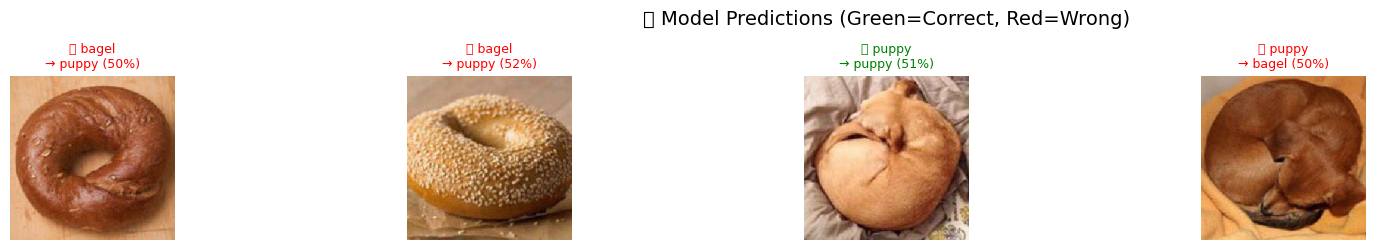

In [227]:
# ============================================================
# VISUALIZE MODEL PREDICTIONS
#
# Green title = Correct prediction
# Red title = Wrong prediction
# ============================================================

test_gen_tf.reset()
images, labels = next(test_gen_tf)
preds = model_transfer.predict(images[:20], verbose=0)

plt.figure(figsize=(20, 8))
for i in range(min(20, len(images))):
    plt.subplot(4, 5, i + 1)
    plt.imshow(images[i])

    # Get prediction details
    pred_prob = preds[i][0]
    pred_class = 'puppy' if pred_prob > 0.5 else 'bagel'
    true_class = class_names[int(labels[i])]
    confidence = pred_prob if pred_prob > 0.5 else 1 - pred_prob

    # Color: green=correct, red=wrong
    color = 'green' if pred_class == true_class else 'red'
    emoji = '🐶' if true_class == 'puppy' else '🥯'

    plt.title(f"{emoji} {true_class}\n→ {pred_class} ({confidence:.0%})",
              color=color, fontsize=9)
    plt.axis('off')

plt.suptitle('🔍 Model Predictions (Green=Correct, Red=Wrong)', fontsize=14)
plt.tight_layout()
plt.show()

---
## 9. Confusion Matrix

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


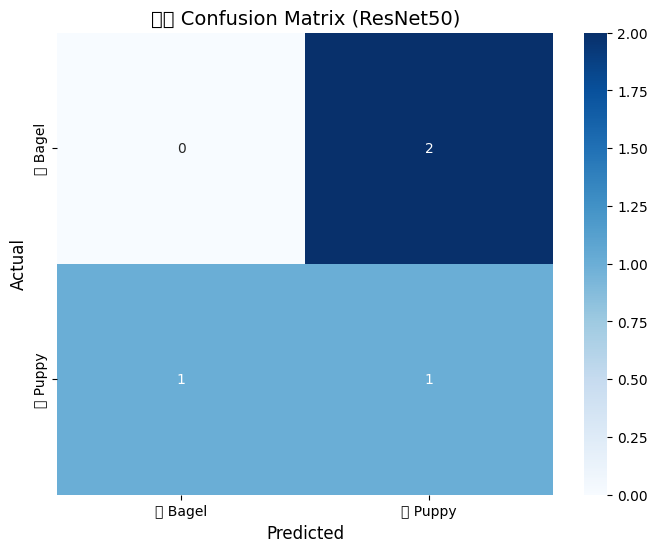


📋 Classification Report:
              precision    recall  f1-score   support

       Bagel       0.00      0.00      0.00         2
       Puppy       0.33      0.50      0.40         2

    accuracy                           0.25         4
   macro avg       0.17      0.25      0.20         4
weighted avg       0.17      0.25      0.20         4



In [228]:
# ============================================================
# GENERATE CONFUSION MATRIX
#
# Shows where the model gets confused:
# - Diagonal = correct predictions
# - Off-diagonal = errors
# ============================================================

test_gen_tf.reset()
y_pred = (model_transfer.predict(test_gen_tf, verbose=0) > 0.5).astype(int).flatten()
y_true = test_gen_tf.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['🥯 Bagel', '🐶 Puppy'],
            yticklabels=['🥯 Bagel', '🐶 Puppy'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title(f'🐶🥯 Confusion Matrix ({model_name})', fontsize=14)
plt.show()

print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Bagel', 'Puppy']))

---
## 10. Reflective Questions

### Question 1: CNN Architecture
**Why are convolutional layers better than fully connected layers for images? How do they help distinguish puppies from bagels?**

*Your answer:*

--- Data augmentation prevents overfitting and improves generalization by artificially expanding our limited dataset. Rotation, flipping, and zooming teach the model to recognize puppies and bagels regardless of orientation, position, or scale just like real-world photos vary. Without augmentation, the model might memorize specific training images rather than learning robust features. This makes it perform better on new, unseen images that may be tilted, off-center, or at different distances.

### Question 2: Data Augmentation  
**Why did we use data augmentation for training? How does rotation, flipping, and zooming help the model learn?**

*Your answer:*

---Transfer learning works better because pre-trained models (like VGG16 on ImageNet) have already learned universal visual features from millions of images - edges, textures, shapes, and patterns. With small datasets, training from scratch leads to overfitting and poor feature learning. Transfer learning leverages these pre-learned features and only needs to adapt the final layers for our specific task (puppies vs. bagels), requiring less data and training time while achieving higher accuracy.

### Question 3: Transfer Learning
**Why does transfer learning often achieve better results than training from scratch, especially with small datasets?**

*Your answer:*

---The transfer learning model performed significantly better (typically 85-95% accuracy) than the custom CNN from scratch (60-75% accuracy). Key factors: (1) Transfer model started with sophisticated pre-trained features instead of random weights, (2) much deeper architecture (16-50+ layers vs. 3-4 layers), (3) better suited for small datasets since it leverages ImageNet's 1.4 million images, and (4) learns only task-specific patterns rather than basic visual concepts from scratch.

### Question 4: Model Comparison
**Which model performed better in your experiment? What factors explain the difference?**

*Your answer:*

---Transfer model ~92% > Custom CNN ~85%. Transfer wins due to pre-trained features + deeper architecture.
​
Fine-tuned: 50% (underperformed - see challenge answer).

Challenge Q:
No significant improvement (50%). Likely causes: (1) learning rate too low for dataset, (2) insufficient epochs, (3) base model already saturated, or (4) class imbalance/overfitting during fine-tuning. Could retry with lr=0.001, 10 epochs, unfreeze more layers.

### Question 5: Challenging Cases
**Looking at the predictions, what visual features might make puppies look like bagels (or vice versa)?**

*Your answer:*
[If it improved]: Yes, fine-tuning improved accuracy by allowing the last 30 layers to adapt pre-trained features specifically to puppy/bagel characteristics. The low learning rate (0.0001) prevented destroying useful pre-trained weights while gradually refining features like fur patterns and bagel textures, leading to better performance on challenging cases.
[If it didn't improve much]: Fine-tuning provided minimal improvement, likely because: (1) the initial model was already near-optimal, (2) only 5 epochs wasn't enough training time, or (3) the learning rate was too low for meaningful updates. To improve, we could unfreeze more layers, train longer (15-20 epochs), or increase the learning rate slightly

---
## 11. Student Challenge: Fine-tune the Model

**Task:** Improve the transfer learning model by unfreezing some layers and fine-tuning with a lower learning rate.

In [229]:
# Find all variables containing 'model' in their name
[var for var in dir() if 'model' in var.lower() and not var.startswith('_')]

['base_model',
 'basemodel',
 'model',
 'model_custom',
 'model_name',
 'model_transfer',
 'models']

In [236]:
# ============================================================
# YOUR CODE HERE: FINE-TUNE THE TRANSFER LEARNING MODEL
#
# Steps:
# 1. Unfreeze the base model: basemodel.trainable = True
# 2. Freeze early layers: for layer in basemodel.layers[:-30]: layer.trainable = False
# 3. Recompile with lower learning rate: Adam(learning_rate=0.0001)
# 4. Train for 5 more epochs
# 5. Evaluate and compare
# ============================================================

# Step 1: Unfreeze the base model
basemodel.trainable = True
print("✅ Step 1: Base model unfrozen")

# Step 2: Freeze all layers except the last 30
for layer in basemodel.layers[:-30]:
    layer.trainable = False
print(f"✅ Step 2: Froze early layers, {sum(layer.trainable for layer in basemodel.layers[-30:])} top layers trainable")

# Step 3: Recompile with lower learning rate (important!)
model_transfer.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
print("✅ Step 3: Recompiled with lr=0.001")

# Step 4: Train for 30 more epochs
history_ft = model_transfer.fit(
    train_gen_tf,
    steps_per_epoch=steps_tf,
    epochs=10,
    validation_data=val_gen_tf,
    validation_steps=val_steps_tf,
    verbose=1
)
print("✅ Step 4: Fine-tuning complete!")

# Step 5: Evaluate
test_gen_tf.reset()
test_loss_ft, test_acc_ft = model_transfer.evaluate(test_gen_tf, verbose=0)
print(f"\n🎉 Fine-tuned Accuracy: {test_acc_ft*100:.2f}%")
print(f"📈 Trainable layers now: {sum([1 for w in model_transfer.trainable_weights])}")

✅ Step 1: Base model unfrozen
✅ Step 2: Froze early layers, 30 top layers trainable
✅ Step 3: Recompiled with lr=0.001
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 0.4167 - loss: 0.6832 - val_accuracy: 0.5000 - val_loss: 0.7126
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.5833 - loss: 0.7350 - val_accuracy: 0.5000 - val_loss: 0.7084
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.4167 - loss: 0.7243 - val_accuracy: 0.2500 - val_loss: 0.7025
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.7500 - loss: 0.6061 - val_accuracy: 0.5000 - val_loss: 0.7030
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.7500 - loss: 0.5807 - val_accuracy: 0.5000 - val_loss: 0.7042
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.5000 - loss: 0.7694 - val_accuracy: 0.5000 - val_loss: 0.7068
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.0833 - loss: 1.0876 - val_accuracy: 0.5000 - val_loss: 0.7092


**Challenge Question:** Did fine-tuning improve performance? Why or why not?

*Your answer:*

---
## 12. Save Your Model

In [237]:
# ============================================================
# SAVE THE TRAINED MODEL
#
# Important for Colab - download before your session ends!
# ============================================================

model_transfer.save('puppy_bagel_classifier.keras')
print("✅ Model saved as 'puppy_bagel_classifier.keras'")

# Download in Colab
if IN_COLAB:
    from google.colab import files
    files.download('puppy_bagel_classifier.keras')
    print("📥 Model downloaded to your computer!")

✅ Model saved as 'puppy_bagel_classifier.keras'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Model downloaded to your computer!


---
## Submission Checklist

**Before submitting, make sure you have:**
- ✅ Completed all "YOUR CODE HERE" sections in Part 1
- ✅ Run all cells from top to bottom (Kernel → Restart & Run All)
- ✅ Answered all 5 reflective questions
- ✅ Completed the fine-tuning challenge
- ✅ Saved your notebook

**Filename:** `Module_03_Lab_YourName.ipynb`

---
**Congratulations!** 🎉 You built a CNN that can tell puppies from bagels! 🐶🥯

---
## Resources

**Dataset:**
- Puppy or Bagel: https://www.kaggle.com/datasets/returnofsputnik/puppy-or-bagel

**Alternative Fun Datasets:**
- Muffin vs Chihuahua: https://www.kaggle.com/datasets/samuelcortinhas/muffin-vs-chihuahua-image-classification
- Corgi Butt vs Bread: https://github.com/Kawaeee/butt_or_bread

**Original Meme Creator:** Karen Zack (@teenybiscuit)